In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1,as_frame=False)


In [33]:
np.random.seed(42)
X= mnist.data
y = mnist.target
print(X.shape)
print(y.shape)
print(np.unique(y))



(70000, 784)
(70000,)
['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


In [3]:
subset_size = 500
indices = []

for digit in np.unique(y):
    digit_indices = np.where(y == digit)[0]
    sample = np.random.choice(digit_indices,subset_size,replace=False)
    indices.append(sample)

indices = np.concatenate(indices)

In [4]:
X_subset = X[indices]
y_subset = y[indices]
print(X_subset.shape)
print(y_subset.shape)

(5000, 784)
(5000,)


In [5]:
df = pd.DataFrame(X_subset)
df['label'] = y_subset
print(df.head())
print(df.shape)

   0  1  2  3  4  5  6  7  8  9  ...  775  776  777  778  779  780  781  782  \
0  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
1  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
2  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
3  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
4  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   

   783  label  
0    0      0  
1    0      0  
2    0      0  
3    0      0  
4    0      0  

[5 rows x 785 columns]
(5000, 785)


### Synt Data Creation

In [6]:
n_samples = 300
n_clusters = 3

centers = np.array([[1, 1], [5, 5], [9, 1]])
std = 0.8

X_synthetic = []
y_synthetic = []

for i, center in enumerate(centers):
    points = np.random.randn(n_samples, 2) * std + center
    X_synthetic.append(points)
    y_synthetic.extend([i] * n_samples)

X_synthetic = np.array(X_synthetic).reshape(-1, 2)
y_synthetic = np.array(y_synthetic)

print(X_synthetic.shape)
print(y_synthetic.shape)

(900, 2)
(900,)


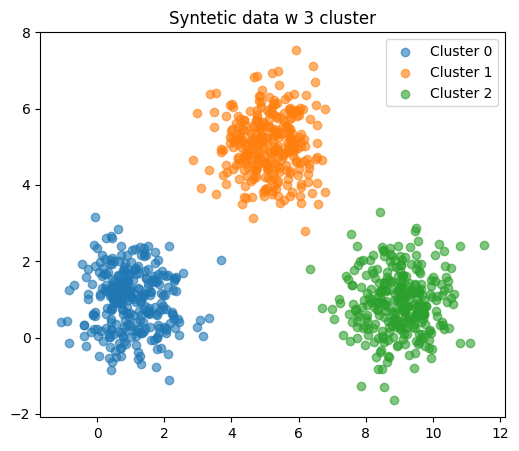

In [7]:
plt.figure(figsize=(6, 5))

for i in range(3):
    mask = y_synthetic == i
    plt.scatter(X_synthetic[mask, 0], X_synthetic[mask, 1], 
                label=f'Cluster {i}', alpha=0.6)

plt.title('Syntetic data w 3 cluster')
plt.legend()
plt.show()

In [8]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

In [9]:
def assign_clusters(X, centroids):
    labels = []
    for point in X:
        distances = [euclidean_distance(point, c) for c in centroids]
        labels.append(np.argmin(distances))
    return np.array(labels)

In [10]:
def update_centroids(X, labels, k):
    centroids = []
    for i in range(k):
        cluster_points = X[labels == i]
        centroids.append(cluster_points.mean(axis=0))
    return np.array(centroids)

In [11]:
def compute_inertia(X, labels, centroids):
    inertia = 0
    for i, point in enumerate(X):
        inertia += euclidean_distance(point, centroids[labels[i]]) ** 2
    return inertia

In [12]:
def initialize_random(X, k):
    indices = np.random.choice(len(X), k, replace=False)
    return X[indices].copy()

In [13]:
def kmeans(X, k, max_iter=100):
    centroids = initialize_random(X, k)
    
    for i in range(max_iter):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)
        
        if np.allclose(centroids, new_centroids):
            break
            
        centroids = new_centroids
    
    inertia = compute_inertia(X, labels, centroids)
    return labels, centroids, inertia

In [14]:
labels, centroids, inertia = kmeans(X_synthetic, k=3)
print("Inertia:", inertia)

Inertia: 1098.0219477553187


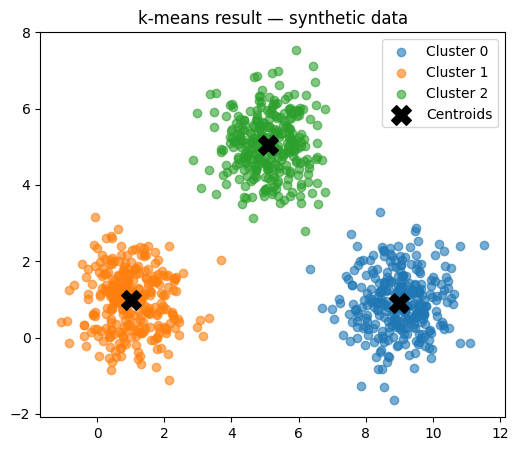

In [ ]:
plt.figure(figsize=(6, 5))

for i in range(3):
    mask = labels == i
    plt.scatter(X_synthetic[mask, 0], X_synthetic[mask, 1],
                alpha=0.6, label=f'Cluster {i}')

plt.scatter(centroids[:, 0], centroids[:, 1],
            c='black', marker='X', s=200, label='Centroids')

plt.title('k-means result - synthetic data')
plt.legend()
plt.show()

### Kmeans++ func

In [16]:
def initialize_plusplus(X, k):
    indices = [np.random.randint(len(X))]
    
    for _ in range(k - 1):
        distances = []
        for point in X:
            d = min(euclidean_distance(point, X[idx]) for idx in indices)
            distances.append(d ** 2)
        
        distances = np.array(distances)
        probabilities = distances / distances.sum()
        next_idx = np.random.choice(len(X), p=probabilities)
        indices.append(next_idx)
    
    return X[np.array(indices)].copy()

In [17]:
def kmeans_plusplus(X, k, max_iter=100):
    centroids = initialize_plusplus(X, k)
    
    for i in range(max_iter):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)
        
        if np.allclose(centroids, new_centroids):
            break
            
        centroids = new_centroids
    
    inertia = compute_inertia(X, labels, centroids)
    return labels, centroids, inertia

In [18]:
labels_pp, centroids_pp, inertia_pp = kmeans_plusplus(X_synthetic, k=3)
print("k-means++ inertia:", inertia_pp)

k-means++ inertia: 1098.0219477553187


In [ ]:
n_trials = 300
k = 3

inertia_random = []
inertia_plusplus = []

for _ in range(n_trials):
    _, _, inertia = kmeans(X_synthetic, k=k)
    inertia_random.append(inertia)
    
    _, _, inertia_pp = kmeans_plusplus(X_synthetic, k=k)
    inertia_plusplus.append(inertia_pp)

print("k-means — mean:", round(np.mean(inertia_random), 2), 
      "| std:", round(np.std(inertia_random), 2))
print("k-means++ — mean:", round(np.mean(inertia_plusplus), 2), 
      "| std:", round(np.std(inertia_plusplus), 2))

k-means    — mean: 1474.96 | std: 1278.36
k-means++  — mean: 1114.3 | std: 281.41


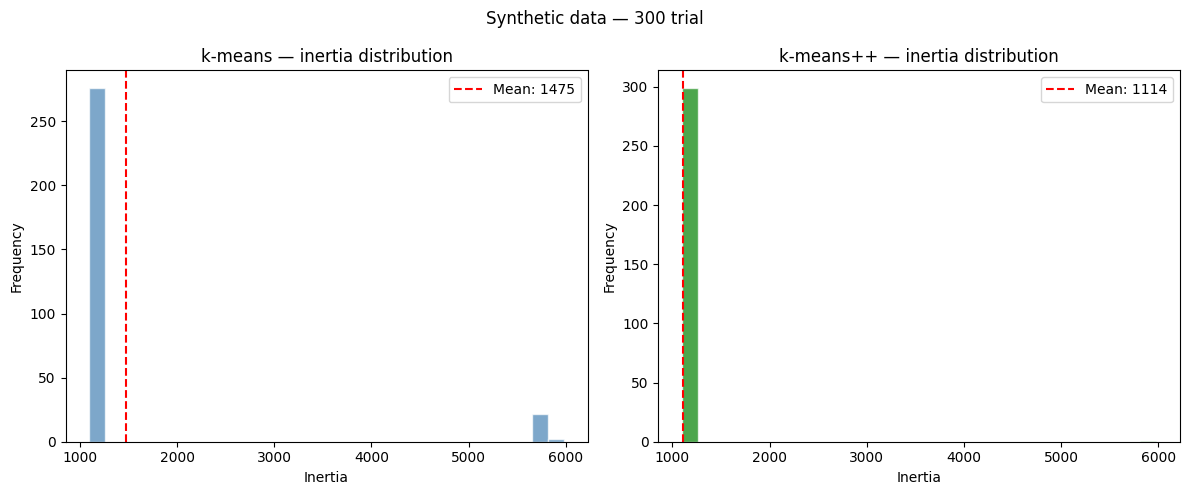

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(inertia_random, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(np.mean(inertia_random), color='red', linestyle='--', label=f'Mean: {np.mean(inertia_random):.0f}')
axes[0].set_title('k-means — inertia distribution')
axes[0].set_xlabel('Inertia')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(inertia_plusplus, bins=30, color='green', alpha=0.7, edgecolor='white')
axes[1].axvline(np.mean(inertia_plusplus), color='red', linestyle='--', label=f'Mean: {np.mean(inertia_plusplus):.0f}')
axes[1].set_title('k-means++ — inertia distribution')
axes[1].set_xlabel('Inertia')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Synthetic data — 300 trial')
plt.tight_layout()
plt.savefig('histogram_synthetic.png', dpi=150)
plt.show()

In [ ]:
n_trials = 100 
k = 10 

inertia_random_mnist = []
inertia_plusplus_mnist = []

for i in range(n_trials):
    _, _, inertia = kmeans(X_subset, k=k)
    inertia_random_mnist.append(inertia)
    
    _, _, inertia_pp = kmeans_plusplus(X_subset, k=k)
    inertia_plusplus_mnist.append(inertia_pp)
    
    if (i+1) % 2 == 0:
        print(f"{i+1} trial done")

print("\nk-means    — mean:", round(np.mean(inertia_random_mnist), 2),
      "| std:", round(np.std(inertia_random_mnist), 2))
print("k-means++  — mean:", round(np.mean(inertia_plusplus_mnist), 2),
      "| std:", round(np.std(inertia_plusplus_mnist), 2))

2 trial done
4 trial done
6 trial done
8 trial done
10 trial done
12 trial done
14 trial done
16 trial done
18 trial done
20 trial done
22 trial done
24 trial done
26 trial done
28 trial done
30 trial done
32 trial done
34 trial done
36 trial done
38 trial done
40 trial done
42 trial done
44 trial done
46 trial done
48 trial done
50 trial done
52 trial done
54 trial done
56 trial done
58 trial done
60 trial done
62 trial done
64 trial done
66 trial done
68 trial done
70 trial done
72 trial done
74 trial done
76 trial done
78 trial done
80 trial done
82 trial done
84 trial done
86 trial done
88 trial done
90 trial done
92 trial done
94 trial done
96 trial done
98 trial done
100 trial done

k-means    — mean: 12842467321.86 | std: 27766622.02
k-means++  — mean: 12845567184.92 | std: 37330196.44


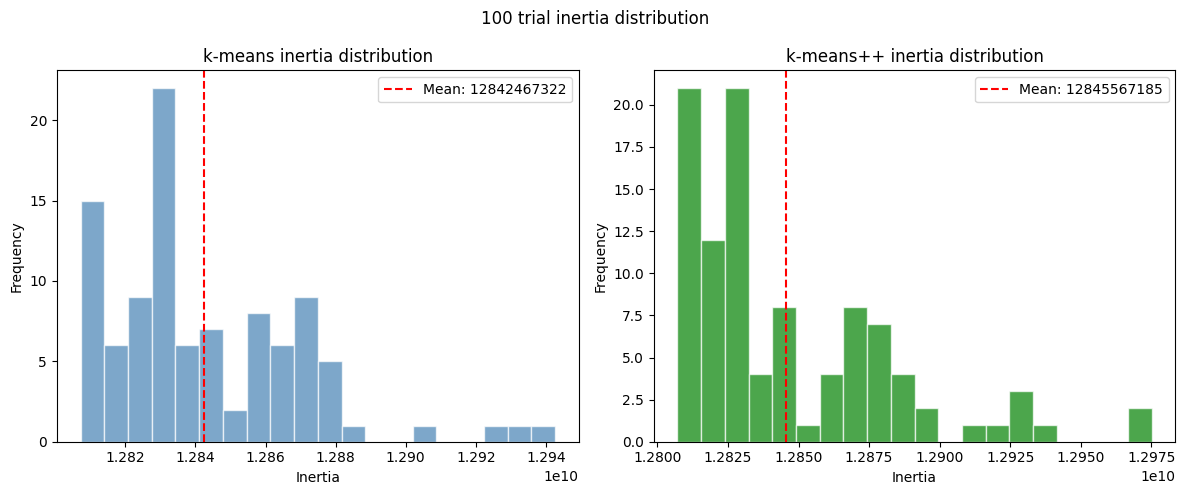

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(inertia_random_mnist, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(np.mean(inertia_random_mnist), color='red', linestyle='--', 
                label=f'Mean: {np.mean(inertia_random_mnist):.0f}')
axes[0].set_title('k-means inertia distribution')
axes[0].set_xlabel('Inertia')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(inertia_plusplus_mnist, bins=20, color='green', alpha=0.7, edgecolor='white')
axes[1].axvline(np.mean(inertia_plusplus_mnist), color='red', linestyle='--',
                label=f'Mean: {np.mean(inertia_plusplus_mnist):.0f}')
axes[1].set_title('k-means++ inertia distribution')
axes[1].set_xlabel('Inertia')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('100 trial inertia distribution')
plt.tight_layout()
plt.savefig('histogram_mnist.png', dpi=150)
plt.show()

In [23]:
best_idx = np.argmin(inertia_random)
worst_idx = np.argmax(inertia_random)

print("Best inertia:", round(inertia_random[best_idx], 2))
print("Worst inertia:", round(inertia_random[worst_idx], 2))

Best inertia: 1098.02
Worst inertia: 5980.38


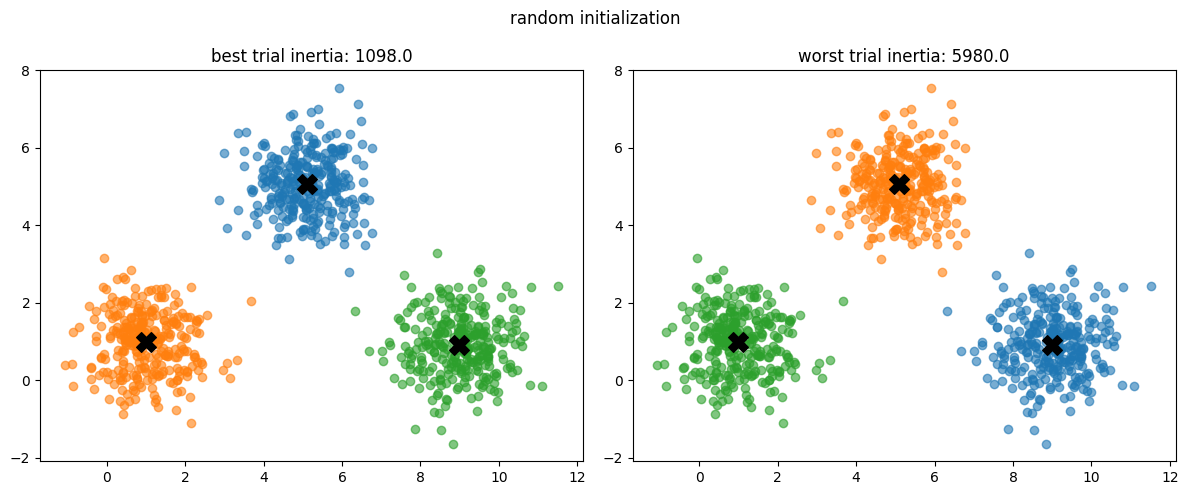

In [24]:
np.random.seed(int(best_idx))
labels_best, centroids_best, _ = kmeans(X_synthetic, k=3)

np.random.seed(int(worst_idx))
labels_worst, centroids_worst, _ = kmeans(X_synthetic, k=3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i in range(3):
    mask = labels_best == i
    axes[0].scatter(X_synthetic[mask, 0], X_synthetic[mask, 1], alpha=0.6)
axes[0].scatter(centroids_best[:, 0], centroids_best[:, 1],
                c='black', marker='X', s=200)
axes[0].set_title(f'best trial inertia: {round(inertia_random[best_idx], 0)}')

for i in range(3):
    mask = labels_worst == i
    axes[1].scatter(X_synthetic[mask, 0], X_synthetic[mask, 1], alpha=0.6)
axes[1].scatter(centroids_worst[:, 0], centroids_worst[:, 1],
                c='black', marker='X', s=200)
axes[1].set_title(f'worst trial inertia: {round(inertia_random[worst_idx], 0)}')

plt.suptitle('random initialization')
plt.tight_layout()
plt.savefig('best_worst_kmeans.png', dpi=150)
plt.show()

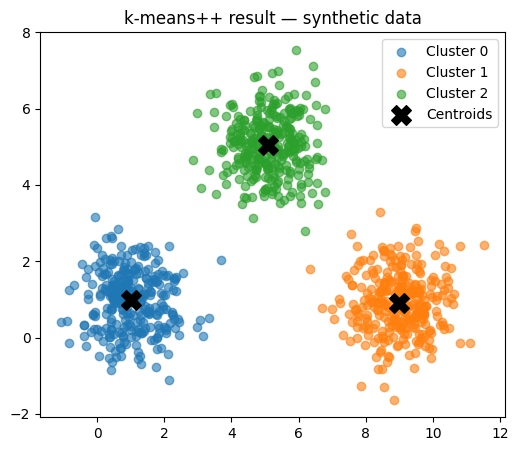

In [35]:
labels_pp, centroids_pp, _ = kmeans_plusplus(X_synthetic, k=3)

plt.figure(figsize=(6, 5))

for i in range(3):
    mask = labels_pp == i
    plt.scatter(X_synthetic[mask, 0], X_synthetic[mask, 1],
                alpha=0.6, label=f'Cluster {i}')

plt.scatter(centroids_pp[:, 0], centroids_pp[:, 1],
            c='black', marker='X', s=200, label='Centroids')

plt.title('k-means++ result — synthetic data')
plt.legend()
plt.savefig('scatter_plusplus.png', dpi=150)
plt.show()

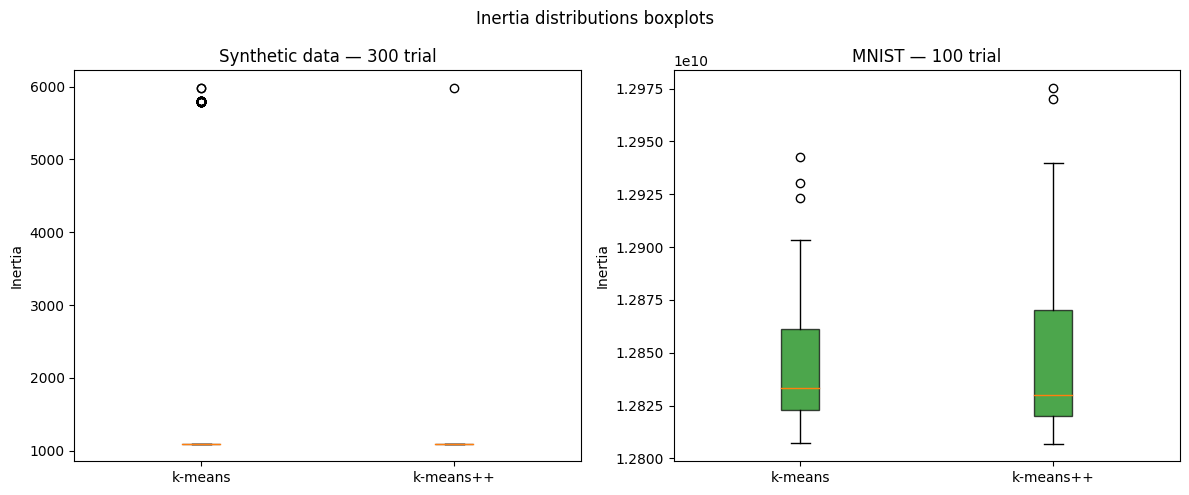

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([inertia_random, inertia_plusplus],
                labels=['k-means', 'k-means++'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),)
axes[0].set_title('Synthetic data — 300 trial')
axes[0].set_ylabel('Inertia')

axes[1].boxplot([inertia_random_mnist, inertia_plusplus_mnist],
                labels=['k-means', 'k-means++'],
                patch_artist=True,
                boxprops=dict(facecolor='green', alpha=0.7))
axes[1].set_title('MNIST — 100 trial')
axes[1].set_ylabel('Inertia')

plt.suptitle('Inertia distributions boxplots')
plt.tight_layout()
plt.savefig('boxplot_comparison.png', dpi=150)
plt.show()